In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Sample - Superstore.csv", encoding='ISO-8859-1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [7]:
for i in df.columns:
  print(i)


Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [9]:
list(df.columns)

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub-category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit']

In [10]:
df.shape

(9994, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  sub-category   9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  sales          9994 non-null   float64
 18  quantity

In [12]:
df.isnull().sum()


,0
row_id,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
country,0
city,0


In [13]:
df.duplicated().sum()
df = df.drop_duplicates()

In [14]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [15]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day
df['profit_margin'] = df['profit'] / df['sales']
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [16]:
df[df['profit'] < 0].shape

(1871, 26)

In [17]:
df['sales'].describe()

,sales
count,9994.000000
mean,229.858001
std,623.245101
min,0.444000
25%,17.280000
50%,54.490000
75%,209.940000
max,22638.480000


In [18]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()

print("Sales:", total_sales)
print("Profit:", total_profit)
print("Orders:", total_orders)
print("Customers:", total_customers)

Sales: 2297200.8603000003
Profit: 286397.0217
Orders: 5009
Customers: 793


In [19]:
df.groupby('category')[['sales','profit']].sum().sort_values(by='sales', ascending=False)

,sales,profit
category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


In [20]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')

In [21]:
df.groupby('sub_category')[['sales','profit']].sum().sort_values(by='profit')

,sales,profit
sub_category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436


In [22]:
category_profit = df.groupby('category')['profit'].sum()
print(category_profit)

category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: profit, dtype: float64


In [23]:
list(df.columns)

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit',
 'year',
 'month',
 'day',
 'profit_margin',
 'shipping_days']

In [24]:
loss_df = df[df['profit'] < 0]

loss_by_category = loss_df.groupby('category')['profit'].sum()
loss_by_subcat = loss_df.groupby('sub_category')['profit'].sum()
print(loss_by_category)
print(loss_by_subcat)

category
Furniture         -60936.1090
Office Supplies   -56615.2585
Technology        -38579.9182
Name: profit, dtype: float64
sub_category
Accessories     -930.6265
Appliances     -8629.6412
Binders       -38510.4964
Bookcases     -12152.2060
Chairs         -9880.8413
Fasteners        -33.1952
Furnishings    -6490.9134
Machines      -30118.6682
Phones         -7530.6235
Storage        -6426.3038
Supplies       -3015.6219
Tables        -32412.1483
Name: profit, dtype: float64


In [25]:
df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

,sales
customer_name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


In [26]:
monthly_sales = df.groupby(['year', 'month'])['sales'].sum().reset_index()

In [27]:
corr = df[['sales','quantity','discount','profit']].corr()
print(corr)

             sales  quantity  discount    profit
sales     1.000000  0.200795 -0.028190  0.479064
quantity  0.200795  1.000000  0.008623  0.066253
discount -0.028190  0.008623  1.000000 -0.219487
profit    0.479064  0.066253 -0.219487  1.000000


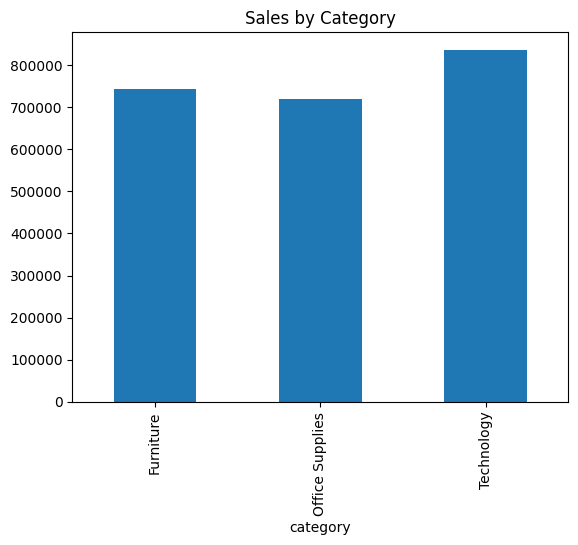

In [28]:
df.groupby('category')['sales'].sum().plot(kind='bar', title='Sales by Category')
plt.show()

In [31]:
region_analysis = df.groupby('region')[['sales','profit']].sum()
print(region_analysis)

               sales       profit
region                           
Central  501239.8908   39706.3625
East     678781.2400   91522.7800
South    391721.9050   46749.4303
West     725457.8245  108418.4489


In [33]:
top_states = df.groupby('state')['sales'].sum().sort_values(ascending=False).head(10)
print(top_states)

state
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: sales, dtype: float64


In [34]:
low_states = df.groupby('state')['profit'].sum().sort_values().head(10)
print(low_states)

state
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: profit, dtype: float64


In [35]:
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

customer_name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: sales, dtype: float64


In [38]:
monthly_sales = df.groupby(['year','month'])['sales'].sum().reset_index()
print(monthly_sales)

    year  month        sales
0   2014      1   14236.8950
1   2014      2    4519.8920
2   2014      3   55691.0090
3   2014      4   28295.3450
4   2014      5   23648.2870
5   2014      6   34595.1276
6   2014      7   33946.3930
7   2014      8   27909.4685
8   2014      9   81777.3508
9   2014     10   31453.3930
10  2014     11   78628.7167
11  2014     12   69545.6205
12  2015      1   18174.0756
13  2015      2   11951.4110
14  2015      3   38726.2520
15  2015      4   34195.2085
16  2015      5   30131.6865
17  2015      6   24797.2920
18  2015      7   28765.3250
19  2015      8   36898.3322
20  2015      9   64595.9180
21  2015     10   31404.9235
22  2015     11   75972.5635
23  2015     12   74919.5212
24  2016      1   18542.4910
25  2016      2   22978.8150
26  2016      3   51715.8750
27  2016      4   38750.0390
28  2016      5   56987.7280
29  2016      6   40344.5340
30  2016      7   39261.9630
31  2016      8   31115.3743
32  2016      9   73410.0249
33  2016     1

In [37]:
yearly_sales = df.groupby('year')['sales'].sum()
print(yearly_sales)

year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: sales, dtype: float64


In [39]:
discount_analysis = df.groupby('discount')[['sales','profit']].mean()
print(discount_analysis)

               sales      profit
discount                        
0.00      226.742074   66.900292
0.10      578.397351   96.055074
0.15      529.971567   27.288298
0.20      209.076940   24.702572
0.30      454.742974  -45.679636
0.32      536.794770  -88.560656
0.40      565.134874 -111.927429
0.45      498.634000 -226.646464
0.50      892.705152 -310.703456
0.60       48.150000  -43.077212
0.70       97.177708  -95.874060
0.80       56.545853 -101.796797


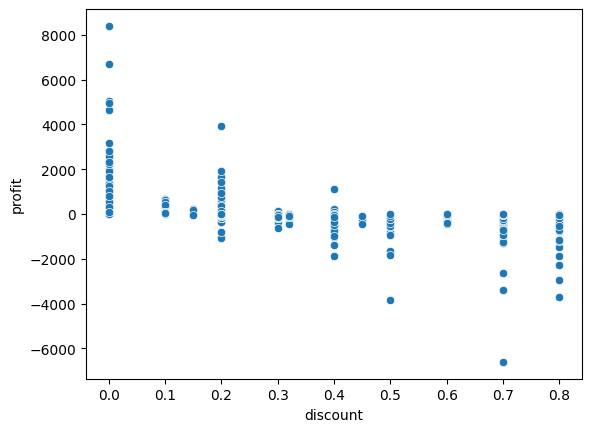

In [40]:
sns.scatterplot(data=df, x='discount', y='profit')
plt.show()

In [41]:
shipping_analysis = df.groupby('ship_mode')['shipping_days'].agg(['mean','max','min'])
print(shipping_analysis)

                    mean  max  min
ship_mode                         
First Class     2.182705    4    1
Same Day        0.044199    1    0
Second Class    3.238046    5    1
Standard Class  5.006535    7    3


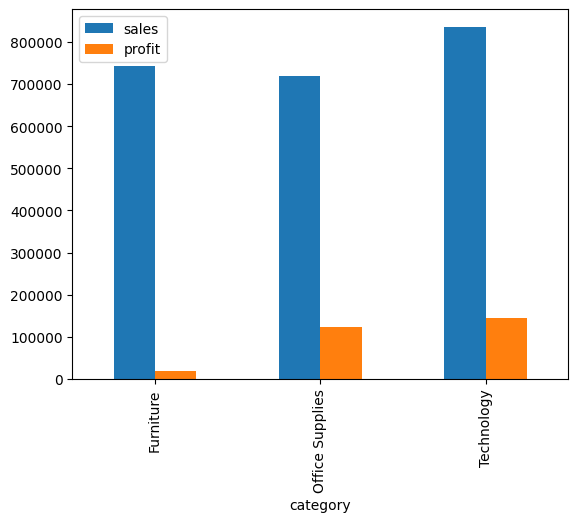

In [42]:
df.groupby('category')[['sales','profit']].sum().plot(kind='bar')
plt.show()

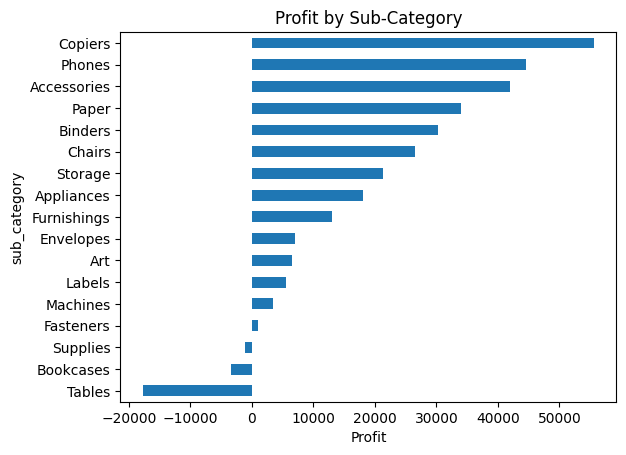

In [44]:
subcat_profit = df.groupby('sub_category')['profit'].sum().sort_values()

subcat_profit.plot(kind='barh', title='Profit by Sub-Category')
plt.xlabel('Profit')
plt.show()

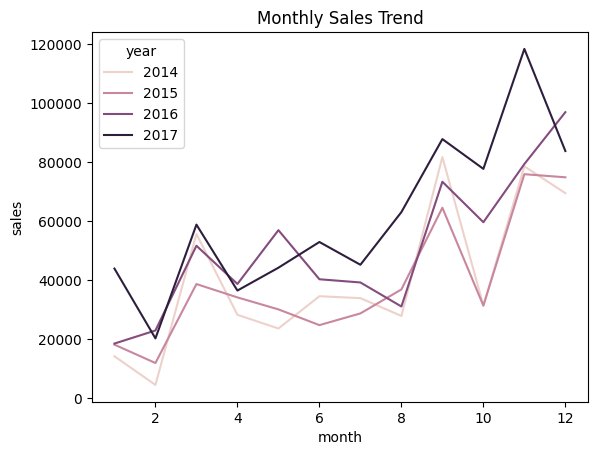

In [45]:
monthly_sales = df.groupby(['year','month'])['sales'].sum().reset_index()

sns.lineplot(data=monthly_sales, x='month', y='sales', hue='year')
plt.title('Monthly Sales Trend')
plt.show()

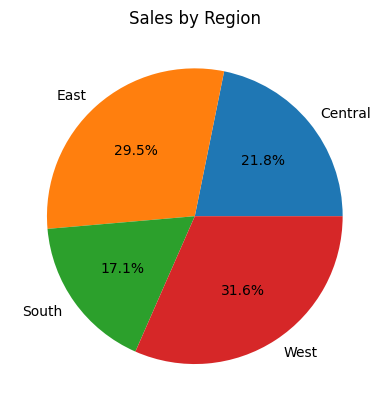

In [46]:
df.groupby('region')['sales'].sum().plot(kind='pie', autopct='%1.1f%%', title='Sales by Region')
plt.ylabel('')
plt.show()

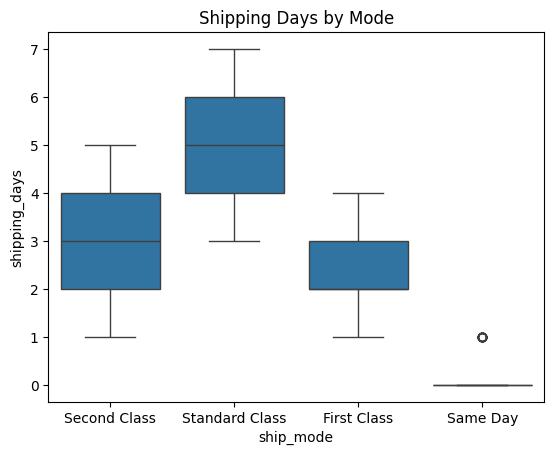

In [47]:
sns.boxplot(data=df, x='ship_mode', y='shipping_days')
plt.title('Shipping Days by Mode')
plt.show()

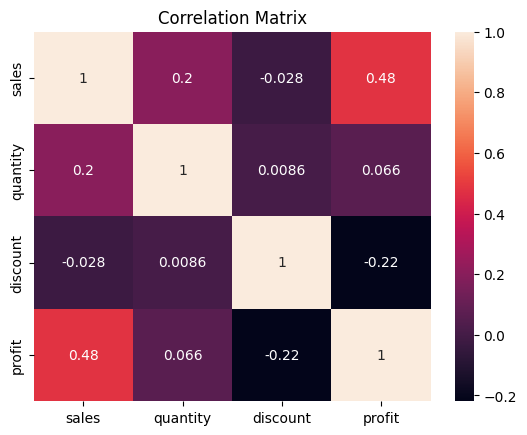

In [48]:
corr = df[['sales','quantity','discount','profit']].corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

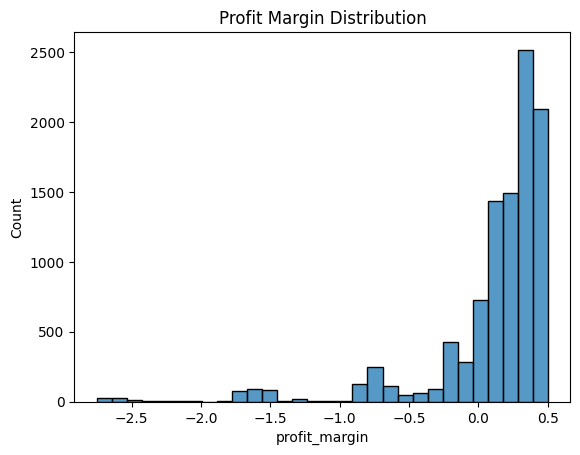

In [49]:
sns.histplot(df['profit_margin'], bins=30)
plt.title('Profit Margin Distribution')
plt.show()